# Оценка частоты дыхания по видео

Цель: оценить частоту дыхания по движению грудной клетки и посмотреть, как на результат влияет слабое освещение.

- 0–57 сек - обычное освещение
- 57–118 сек - слабое освещение
- 118 сек – конец - обычное освещение

Используются готовые модели MediaPipe Pose Landmarker для поиска ключевых точек тела и RAFT Small для расчета оптического потока. После этого сигнал очищается и по его пикам оценивается частота дыхания

## Импорты и параметры

In [8]:
import csv
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.functional as F

from scipy.signal import detrend, butter, filtfilt, find_peaks
from torchvision.models.optical_flow import raft_small, Raft_Small_Weights

VIDEO_PATH = "video.MOV"
MODEL_PATH = "pose_landmarker_full.task"

## Проверка видео

In [9]:
video = cv2.VideoCapture(VIDEO_PATH)

fps = video.get(cv2.CAP_PROP_FPS)
frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frames/fps

video.release()

print(f"ФПС: {fps:.2f}")
print(f"Количество кадров: {frames}")
print(f"Длительность видео: {duration:.2f} сек")

ФПС: 28.00
Количество кадров: 5059
Длительность видео: 180.67 сек


## Определение ключевых точек тела (MediaPipe Pose)

In [10]:
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
RunningMode = mp.tasks.vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=RunningMode.VIDEO,
    num_poses=1
)

video = cv2.VideoCapture(VIDEO_PATH)

with open("chest_coord.csv", "w", newline="", encoding="utf-8") as cc:
    w = csv.writer(cc)
    w.writerow(["кадр", "время", "x1", "y1", "x2", "y2"])

    with PoseLandmarker.create_from_options(options) as landmarker:
        i = 0
        detected = 0

        while True:
            ok, frame = video.read()
            if not ok:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            res = landmarker.detect_for_video(img, int(i * 1000 / fps))

            if res.pose_landmarks:
                detected += 1
                points = []

                for p in res.pose_landmarks[0]:
                    x = int(p.x * width)
                    y = int(p.y * height)

                    points.append((x, y))

                l_shoulder, r_shoulder = points[11], points[12]
                l_hip, r_hip = points[23], points[24]

                shoulder_x = (l_shoulder[0]+r_shoulder[0])//2
                shoulder_y = (l_shoulder[1]+ r_shoulder[1])//2
                hip_x = (l_hip[0] + r_hip[0])//2
                hip_y = (l_hip[1] + r_hip[1])//2

                shoulder_width = abs(r_shoulder[0]-l_shoulder[0])
                center_x = (shoulder_x+hip_x) // 2
                half_width = int(shoulder_width * 0.3)

                x1 = max(0, center_x - half_width)
                x2 = min(width - 1, center_x + half_width)
                y1 = max(0, int(shoulder_y + 0.2 * (hip_y - shoulder_y)))
                y2 = min(height-1, int(shoulder_y + 0.5 * (hip_y - shoulder_y)))

                w.writerow([i, i/fps, x1, y1, x2, y2])
            i += 1

video.release()
print(f"Кадров с обнаруженной позой: {detected}/{frames}")

Кадров с обнаруженной позой: 5059/5059


##  RAFT optical flow

In [11]:
chest_coord = pd.read_csv("chest_coord.csv").dropna()

x1 = int(chest_coord["x1"].median())
y1 = int(chest_coord["y1"].median())
x2 = int(chest_coord["x2"].median())
y2 = int(chest_coord["y2"].median())

chest_height = y2-y1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = Raft_Small_Weights.DEFAULT
model = raft_small(weights=weights).to(device).eval()
transforms = weights.transforms()

def to_tensor(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0)
    return F.resize(tensor, [256, 256], antialias=False)

video = cv2.VideoCapture(VIDEO_PATH)

prev = None
total_movement = 0.0
rows = []

with torch.inference_mode():
    i = 0

    while True:
        ok, frame = video.read()
        if not ok:
            break

        if i%10 != 0:
            i += 1
            continue

        chest = frame[y1:y2, x1:x2]

        if prev is None:
            prev = chest.copy()
            i += 1
            continue

        img1, img2 = transforms(to_tensor(prev), to_tensor(chest))
        flow = model(img1.to(device), img2.to(device), num_flow_updates=8)[-1][0].cpu().numpy()

        vert_flow = flow[1]
        vert_movement = float(np.median(vert_flow)) * chest_height / 256

        total_movement += float(vert_movement)
        time_sec = i / fps
        rows.append([time_sec, float(vert_movement), total_movement])

        prev = chest.copy()
        i += 1

video.release()
signal = pd.DataFrame(rows,columns=["время", "dy_px", "total_movement_px"])

signal.to_csv("optical_flow.csv", index=False)

print(f"Колво отчетов сигнала: {len(signal)}")

Колво отчетов сигнала: 505


## Исходный сигнал оптического потока

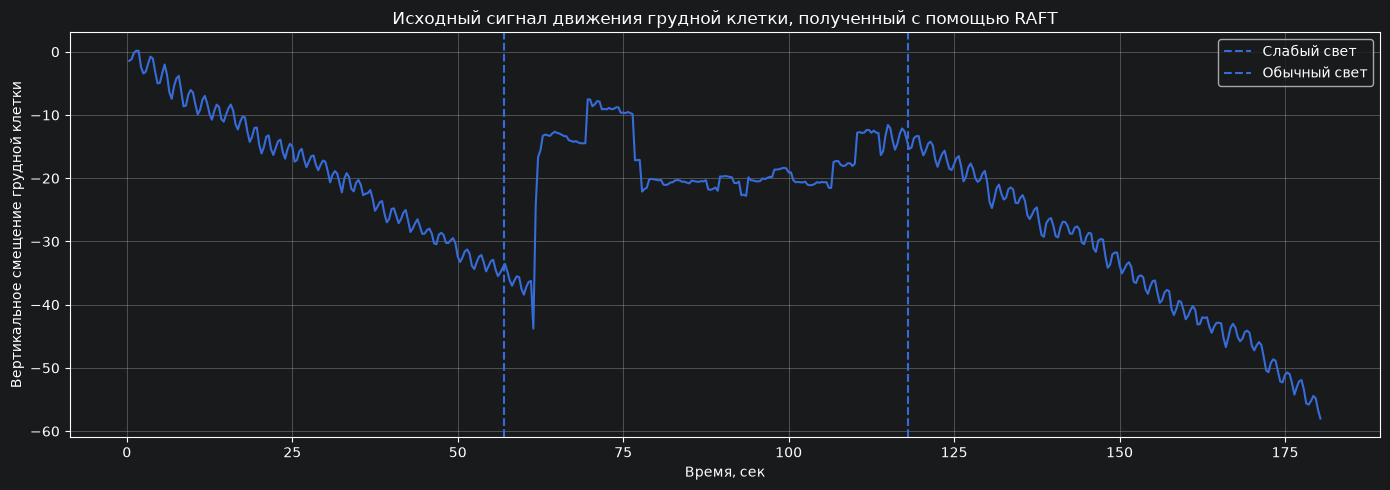

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(signal["время"], signal["total_movement_px"])
plt.axvline(57, linestyle="--", label="Слабый свет")
plt.axvline(118, linestyle="--", label="Обычный свет")
plt.xlabel("Время, сек")
plt.ylabel("Вертикальное смещение грудной клетки")
plt.title("Исходный сигнал движения грудной клетки, полученный с помощью RAFT")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## Фильтрация и оценка частоты дыхания

In [13]:
time = signal["время"].to_numpy()
raw = signal["total_movement_px"].to_numpy()

signal_rate = fps/10

clean = detrend(raw)
b,a = butter(5, [0.05, 1.0],btype="bandpass", fs=signal_rate)
filtered = filtfilt(b,a,clean)

peaks, _ = find_peaks(filtered, distance=int(signal_rate * 1.0), prominence=np.std(filtered) * 0.1)

detected_breaths = len(peaks)
ground_truth_rr = 90/duration*60
predicted_rr = detected_breaths/duration*60
abs_error = abs(ground_truth_rr - predicted_rr)

print(f"Количество обнаруженных пиков: {detected_breaths}")
print(f"Фактическая частота дыхания: {ground_truth_rr:.2f} дых/мин")
print(f"Рассчитанная частота дыхания: {predicted_rr:.2f} дых/мин")
print(f"Абсолютная ошибка: {abs_error:.2f} дых/мин")

Количество обнаруженных пиков: 84
Фактическая частота дыхания: 29.89 дых/мин
Рассчитанная частота дыхания: 27.90 дых/мин
Абсолютная ошибка: 1.99 дых/мин


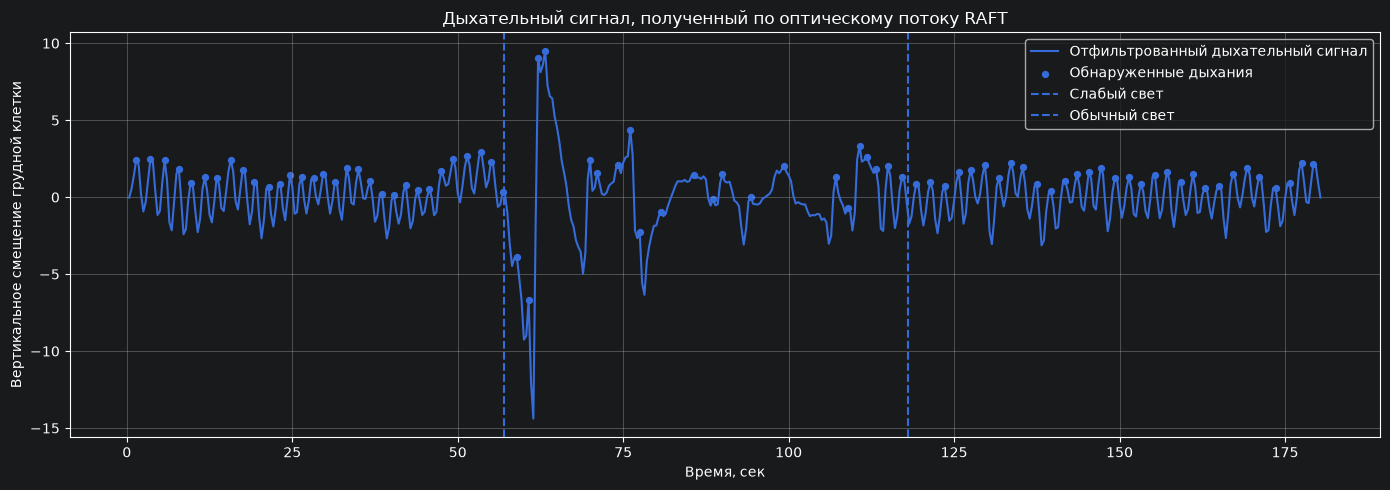

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(time, filtered, label="Отфильтрованный дыхательный сигнал")
plt.scatter(time[peaks], filtered[peaks], s=18, label="Обнаруженные дыхания")
plt.axvline(57, linestyle="--", label="Слабый свет")
plt.axvline(118, linestyle="--", label="Обычный свет")
plt.xlabel("Время, сек")
plt.ylabel("Вертикальное смещение грудной клетки")
plt.title("Дыхательный сигнал, полученный по оптическому потоку RAFT")
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("result.png", dpi=200)
plt.show()

## Результат

In [15]:
peak_times = time[peaks]

segments = [
    ("Нормальный свет 0–57 сек", 0, 57),
    ("Слабый свет 57–118 сек", 57, 118),
    ("Нормальный свет 118 сек - конец", 118, duration)
]

for name, start, end in segments:
    count = np.sum((peak_times >= start) & (peak_times < end))
    rr = count/(end - start) * 60
    print(f"{name}: {count} пиков, {rr:.2f} дых/мин")

Нормальный свет 0–57 сек: 31 пиков, 32.63 дых/мин
Слабый свет 57–118 сек: 22 пиков, 21.64 дых/мин
Нормальный свет 118 сек - конец: 31 пиков, 29.68 дых/мин
